# Traffic Demand Prediction Pipeline
End-to-end pipeline with EDA, Feature Engineering, and Ensemble Modeling.


In [1]:
import numpy as np
import pandas as pd
import json
import os
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit, KFold
from sklearn.metrics import r2_score
import catboost as cb
import lightgbm as lgb
import xgboost as xgb

# Plotting configuration
%matplotlib inline
sns.set_style('whitegrid')
sns.set_palette('husl')



## Helper Functions


In [2]:
_BASE32 = '0123456789bcdefghjkmnpqrstuvwxyz'
_DECODEMAP = {c: i for i, c in enumerate(_BASE32)}

def decode_geohash(gh):
    if pd.isna(gh): return np.nan, np.nan
    lat_i, lon_i = (-90.0, 90.0), (-180.0, 180.0)
    is_even = True
    for c in str(gh):
        cd = _DECODEMAP.get(c, 0)
        for mask in [16, 8, 4, 2, 1]:
            if is_even:
                mid = (lon_i[0] + lon_i[1]) / 2
                lon_i = (mid, lon_i[1]) if cd & mask else (lon_i[0], mid)
            else:
                mid = (lat_i[0] + lat_i[1]) / 2
                lat_i = (mid, lat_i[1]) if cd & mask else (lat_i[0], mid)
            is_even = not is_even
    return (lat_i[0]+lat_i[1])/2, (lon_i[0]+lon_i[1])/2

def target_encode_oof(train_df, test_df, group_col, target='demand', smoothing=10, n_splits=5):
    feat_name = f'te_{group_col}'
    global_mean = train_df[target].mean()
    
    train_df[feat_name] = np.nan
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for train_idx, val_idx in kf.split(train_df):
        X_tr, X_val = train_df.iloc[train_idx], train_df.iloc[val_idx]
        stats = X_tr.groupby(group_col)[target].agg(['mean', 'count'])
        smooth = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
        val_key = X_val[group_col]
        train_df.loc[val_idx, feat_name] = val_key.map(smooth).fillna(global_mean).values
        
    stats = train_df.groupby(group_col)[target].agg(['mean', 'count'])
    smooth = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
    test_key = test_df[group_col]
    test_df[feat_name] = test_key.map(smooth).fillna(global_mean).astype(np.float32)
    train_df[feat_name] = train_df[feat_name].astype(np.float32)
    
    return train_df, test_df



## Phase 1: Data Loading & Preprocessing


In [3]:
train = pd.read_csv('dataset/train.csv')
test = pd.read_csv('dataset/test.csv')
print(f"Train: {train.shape}, Test: {test.shape}")

def parse_timestamp(ts_str):
    parts = str(ts_str).split(':')
    return int(parts[0]), int(parts[1]) if len(parts) > 1 else 0

for df in [train, test]:
    parsed = df['timestamp'].apply(lambda x: pd.Series(parse_timestamp(x)))
    df['hour'] = parsed[0].astype(np.int8)
    df['minute'] = parsed[1].astype(np.int8)
    df['time_slot'] = (df['hour'] * 4 + df['minute'] // 15).astype(np.int8)
    df['time_order'] = (df['day'] * 96 + df['time_slot']).astype(np.int32)

temp_median = train['Temperature'].median()
train['Temperature'] = train['Temperature'].fillna(temp_median)
test['Temperature'] = test['Temperature'].fillna(temp_median)

road_mode = train['RoadType'].mode()[0]
train['RoadType'] = train['RoadType'].fillna(road_mode)
test['RoadType'] = test['RoadType'].fillna(road_mode)

weather_mode = train['Weather'].mode()[0]
train['Weather'] = train['Weather'].fillna(weather_mode)
test['Weather'] = test['Weather'].fillna(weather_mode)

print(f"Demand range: [{train['demand'].min():.6f}, {train['demand'].max():.6f}]")

cat_cols = ['geohash', 'RoadType', 'Weather', 'LargeVehicles', 'Landmarks']
for col in cat_cols:
    train[col] = train[col].astype('category')
    test[col] = test[col].astype('category')



Train: (77299, 11), Test: (41778, 10)


Demand range: [0.000001, 1.000000]


In [8]:
# .info() tells us:
# - Column names
# - Non-null counts (so we can spot missing values)
# - Data types (int, float, object/string)

print("=" * 50)
print("TRAIN INFO")
print("=" * 50)
train.info()

print("\n")
print("=" * 50)
print("TEST INFO")
print("=" * 50)
test.info()

TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


TEST INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41778 entries, 0 to 41777
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          41778 non-null  i

In [9]:
# isnull().sum() counts missing values per column
# We calculate percentage too so we know severity

print("=== MISSING VALUES IN TRAIN ===")
missing_train = pd.DataFrame({
    'Missing Count': train.isnull().sum(),
    'Missing %': (train.isnull().sum() / len(train) * 100).round(2)
})
print(missing_train[missing_train['Missing Count'] > 0])

print("\n=== MISSING VALUES IN TEST ===")
missing_test = pd.DataFrame({
    'Missing Count': test.isnull().sum(),
    'Missing %': (test.isnull().sum() / len(test) * 100).round(2)
})
print(missing_test[missing_test['Missing Count'] > 0])

=== MISSING VALUES IN TRAIN ===
             Missing Count  Missing %
RoadType               600       0.78
Temperature           2495       3.23
Weather                797       1.03

=== MISSING VALUES IN TEST ===
             Missing Count  Missing %
RoadType               324       0.78
Temperature           1349       3.23
Weather                431       1.03


## Exploratory Data Analysis (EDA)

### Target Distribution
Analyzing the traffic demand target variable. The raw demand is heavily right-skewed.


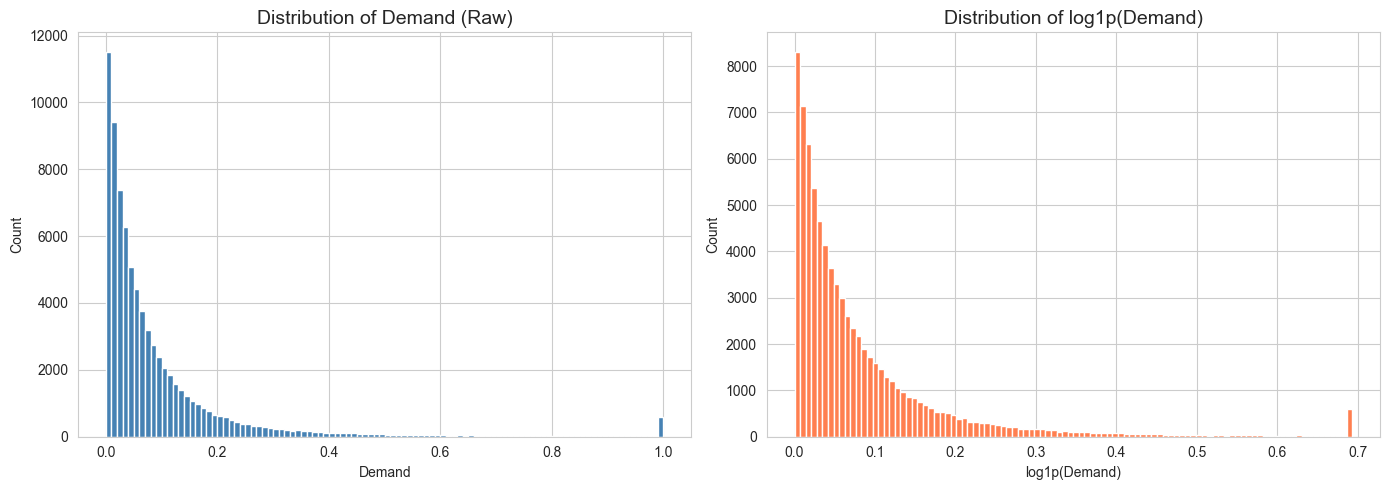


=== DEMAND STATISTICS ===
count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train['demand'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Demand (Raw)', fontsize=14)
axes[0].set_xlabel('Demand')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(train['demand']), bins=100, color='coral', edgecolor='white')
axes[1].set_title('Distribution of log1p(Demand)', fontsize=14)
axes[1].set_xlabel('log1p(Demand)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\n=== DEMAND STATISTICS ===")
print(train['demand'].describe())



### Categorical Variables Unique Counts


In [5]:
categorical_cols = ['geohash', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather']
print("=== UNIQUE VALUE COUNTS ===")
for col in categorical_cols:
    print(f"\n{col}: {train[col].nunique()} unique values")
    print(train[col].value_counts(dropna=False).head(6))



=== UNIQUE VALUE COUNTS ===

geohash: 1249 unique values
geohash
qp03mg    105
qp03pr    105
qp03q9    105
qp03qd    105
qp03qf    105
qp03qg    105
Name: count, dtype: int64

RoadType: 3 unique values
RoadType
Residential    69830
Street          3909
Highway         3560
Name: count, dtype: int64

LargeVehicles: 2 unique values
LargeVehicles
Not Allowed    50673
Allowed        26626
Name: count, dtype: int64

Landmarks: 2 unique values
Landmarks
Yes    52042
No     25257
Name: count, dtype: int64

Weather: 4 unique values
Weather
Sunny    28514
Rainy    20824
Foggy    20243
Snowy     7718
Name: count, dtype: int64


### Day Distribution & Timestamp Sample
Critical insight for time-series forecasting: observing the days present in Train vs Test.
The training dataset contains data for Day 48 and Day 49, whereas the test set is solely for Day 49.


In [6]:
# CRITICAL INSIGHT: Train has day 48 AND 49, Test only has day 49
# This is a TIME-SERIES style problem — we predict the future (day 49) from the past (day 48)

print("=== DAY DISTRIBUTION ===")
print("Train days:", sorted(train['day'].unique()))
print("Test days :", sorted(test['day'].unique()))
print() 
print(train['day'].value_counts())

print("\n=== TIMESTAMP SAMPLE ===")
print("Total unique timestamps:", train['timestamp'].nunique())
print("Sample timestamps:", sorted(train['timestamp'].unique())[:10])
print("... (96 total = 24 hours × 4 slots per hour = 15-min intervals)\n")


=== DAY DISTRIBUTION ===
Train days: [48, 49]
Test days : [49]

day
48    46603
49    30696
Name: count, dtype: int64

=== TIMESTAMP SAMPLE ===
Total unique timestamps: 96
Sample timestamps: ['0:0', '0:15', '0:30', '0:45', '10:0', '10:15', '10:30', '10:45', '11:0', '11:15']
... (96 total = 24 hours × 4 slots per hour = 15-min intervals)


### Temporal Patterns
Visualizing the average demand by hour of the day.


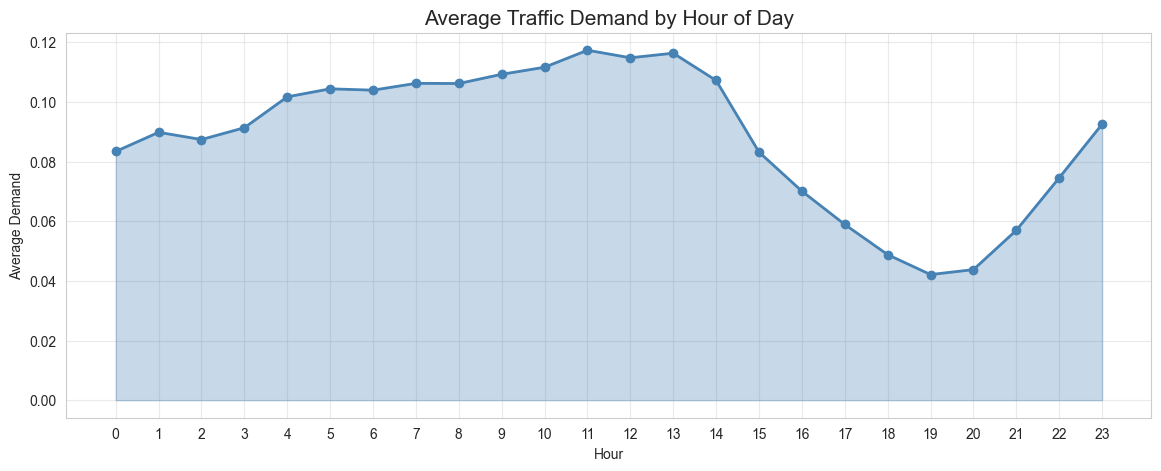

In [ ]:
hourly_demand = train.groupby('hour')['demand'].mean().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(hourly_demand['hour'], hourly_demand['demand'], 
         marker='o', color='steelblue', linewidth=2, markersize=6)
plt.fill_between(hourly_demand['hour'], hourly_demand['demand'], alpha=0.3, color='steelblue')
plt.title('Average Traffic Demand by Hour of Day', fontsize=15)
plt.xlabel('Hour')
plt.ylabel('Average Demand')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.4)
plt.show()



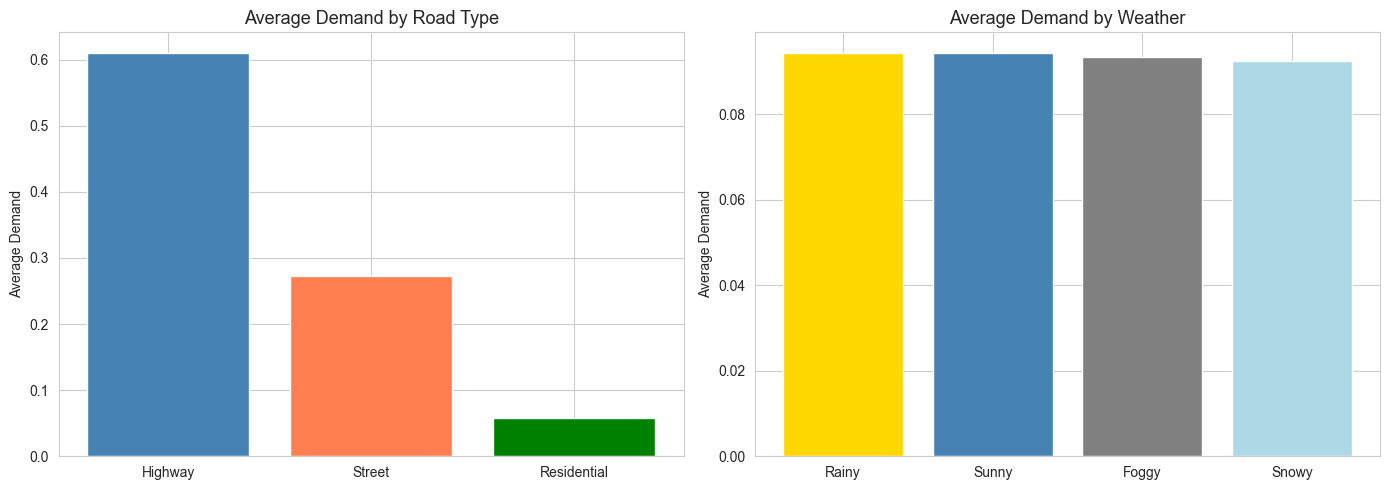

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Demand by Road Type
road_demand = train.groupby('RoadType')['demand'].mean().sort_values(ascending=False)
axes[0].bar(road_demand.index, road_demand.values, color=['steelblue','coral','green'])
axes[0].set_title('Average Demand by Road Type', fontsize=13)
axes[0].set_ylabel('Average Demand')

# Demand by Weather
weather_demand = train.groupby('Weather')['demand'].mean().sort_values(ascending=False)
axes[1].bar(weather_demand.index, weather_demand.values, 
            color=['gold','steelblue','gray','lightblue'])
axes[1].set_title('Average Demand by Weather', fontsize=13)
axes[1].set_ylabel('Average Demand')

plt.tight_layout()
plt.show()

In [16]:
# Geohash is a location code — like a postal code for GPS coordinates
# Understanding overlap between train and test geohashes is critical

train_geo = set(train['geohash'].unique())
test_geo  = set(test['geohash'].unique())

print(f"Unique geohashes in Train : {len(train_geo)}")
print(f"Unique geohashes in Test  : {len(test_geo)}")
print(f"Geohashes in BOTH         : {len(train_geo & test_geo)}")
print(f"In Test but NOT in Train  : {len(test_geo - train_geo)}")
print()
print("  Only 10 test geohashes are unseen — 99.2% overlap!")
print("  We can safely use geohash-level aggregations as features")

Unique geohashes in Train : 1249
Unique geohashes in Test  : 1190
Geohashes in BOTH         : 1180
In Test but NOT in Train  : 10

  Only 10 test geohashes are unseen — 99.2% overlap!
  We can safely use geohash-level aggregations as features


✅ Correlation between Day 48 and Day 49 demand: 0.7924
   (For same geohash + timestamp)

Test rows that HAVE a day48 lag: 37136 / 41778
This single feature alone will be incredibly powerful!


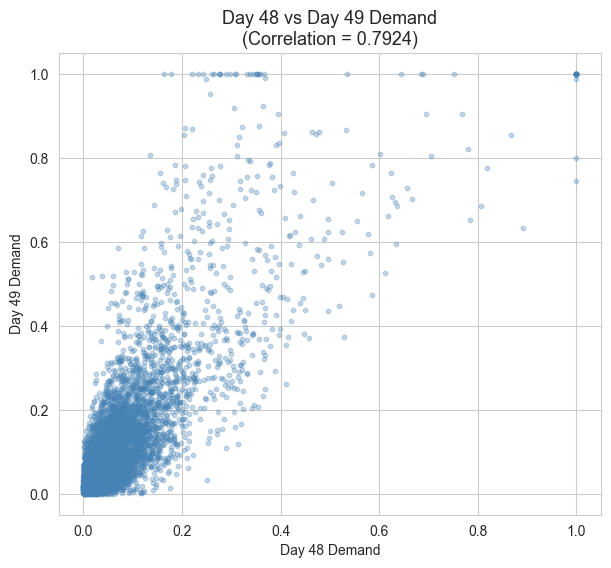

In [17]:
# MOST IMPORTANT CELL IN THE ENTIRE EDA
# Since train has day 48 and test is day 49,
# we can use day 48 demand as a "lag feature" to predict day 49 demand
# This is like saying: "Yesterday's 8am traffic predicts today's 8am traffic"

day48 = train[train['day'] == 48][['geohash', 'timestamp', 'demand']].rename(
    columns={'demand': 'lag_demand_day48'}
)
day49_train = train[train['day'] == 49][['geohash', 'timestamp', 'demand']].rename(
    columns={'demand': 'lag_day49'}
)

# Merge day48 and day49 on same geohash+timestamp
overlap = day48.merge(day49_train, on=['geohash', 'timestamp'], how='inner')

# Calculate correlation
corr = overlap['lag_demand_day48'].corr(overlap['lag_day49'])
print(f" Correlation between Day 48 and Day 49 demand: {corr:.4f}")
print(f"   (For same geohash + timestamp)")
print()
print(f"Test rows that HAVE a day48 lag: {len(day48.merge(test, on=['geohash','timestamp'], how='inner'))} / {len(test)}")
print("This single feature alone will be incredibly powerful!")

# Visualize
plt.figure(figsize=(7,6))
plt.scatter(overlap['lag_demand_day48'], overlap['lag_day49'], 
            alpha=0.3, s=10, color='steelblue')
plt.xlabel('Day 48 Demand')
plt.ylabel('Day 49 Demand')
plt.title(f'Day 48 vs Day 49 Demand\n(Correlation = {corr:.4f})', fontsize=13)
plt.show()

## Phase 2: Feature Engineering


In [7]:
unique_gh = set(train['geohash'].astype(str).unique()) | set(test['geohash'].astype(str).unique())
decode_map = {gh: decode_geohash(gh) for gh in unique_gh}

for df in [train, test]:
    gh_str = df['geohash'].astype(str)
    df['latitude'] = gh_str.map(lambda x: decode_map[x][0])
    df['longitude'] = gh_str.map(lambda x: decode_map[x][1])
    df['geohash_4'] = gh_str.str[:4]
    df['geohash_5'] = gh_str.str[:5]

center_lat = train['latitude'].median()
center_lon = train['longitude'].median()
for df in [train, test]:
    df['dist_to_center'] = np.sqrt((df['latitude'] - center_lat)**2 + (df['longitude'] - center_lon)**2)

for df in [train, test]:
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)
    df['minute_sin'] = np.sin(2 * np.pi * df['minute'] / 60.0)
    df['minute_cos'] = np.cos(2 * np.pi * df['minute'] / 60.0)
    df['slot_sin'] = np.sin(2 * np.pi * df['time_slot'] / 96.0)
    df['slot_cos'] = np.cos(2 * np.pi * df['time_slot'] / 96.0)
    df['day_sin'] = np.sin(2 * np.pi * df['day'] / 7.0)
    df['day_cos'] = np.cos(2 * np.pi * df['day'] / 7.0)

for df in [train, test]:
    df['is_rush_hour'] = ((df['hour'].between(7, 10)) | (df['hour'].between(16, 19))).astype(np.int8)
    df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype(np.int8)
    df['is_low_demand'] = df['hour'].between(17, 20).astype(np.int8)
    df['is_peak'] = df['hour'].between(10, 14).astype(np.int8)
    df['frac_hour'] = df['hour'] + df['minute'] / 60.0

for df in [train, test]:
    df['road_weather'] = df['RoadType'].astype(str) + '_' + df['Weather'].astype(str)
    df['road_vehicles'] = df['RoadType'].astype(str) + '_' + df['LargeVehicles'].astype(str)
    
    road_map = {'Residential': 0, 'Street': 1, 'Highway': 2}
    df['road_encoded'] = df['RoadType'].astype(str).map(road_map).fillna(0).astype(np.int8)
    df['road_capacity'] = df['road_encoded'] * df['NumberofLanes']
    df['lanes_sq'] = df['NumberofLanes'] ** 2
    df['is_highway'] = (df['RoadType'].astype(str) == 'Highway').astype(np.int8)
    df['is_street'] = (df['RoadType'].astype(str) == 'Street').astype(np.int8)
    df['is_high_capacity'] = (df['NumberofLanes'] >= 4).astype(np.int8)
    df['is_bad_weather'] = df['Weather'].astype(str).isin(['Rainy', 'Snowy', 'Foggy']).astype(np.int8)
    df['temp_bad_weather'] = df['Temperature'] * df['is_bad_weather']
    df['temp_highway'] = df['Temperature'] * df['is_highway']
    df['has_landmark'] = (df['Landmarks'].astype(str) == 'Yes').astype(np.int8)
    df['large_vehicles_allowed'] = (df['LargeVehicles'].astype(str) == 'Allowed').astype(np.int8)
    df['road_score'] = df['road_encoded'] * 3 + df['NumberofLanes']
    df['road_hour'] = df['road_encoded'] * 24 + df['hour']
    df['highway_rush'] = df['is_highway'] * df['is_rush_hour']
    df['highway_peak'] = df['is_highway'] * df['is_peak']
    df['lanes_peak'] = df['NumberofLanes'] * df['is_peak']

geo_counts = train['geohash'].value_counts().to_dict()
total = len(train)
for df in [train, test]:
    df['geohash_freq'] = df['geohash'].astype(str).map(geo_counts).fillna(0) / total

for col in ['geohash_4', 'geohash_5', 'road_weather', 'road_vehicles']:
    train[col] = train[col].astype('category')
    test[col] = test[col].astype('category')

# OOF Target Encoding
train['gh_hour'] = train['geohash'].astype(str) + '_' + train['hour'].astype(str)
test['gh_hour'] = test['geohash'].astype(str) + '_' + test['hour'].astype(str)
train['rt_hour'] = train['RoadType'].astype(str) + '_' + train['hour'].astype(str)
test['rt_hour'] = test['RoadType'].astype(str) + '_' + test['hour'].astype(str)
train['gh_rt'] = train['geohash'].astype(str) + '_' + train['RoadType'].astype(str)
test['gh_rt'] = test['geohash'].astype(str) + '_' + test['RoadType'].astype(str)
train['gh4_hour'] = train['geohash_4'].astype(str) + '_' + train['hour'].astype(str)
test['gh4_hour'] = test['geohash_4'].astype(str) + '_' + test['hour'].astype(str)

smooth_map = {
    'geohash': 10, 'geohash_4': 20, 'geohash_5': 15,
    'RoadType': 50, 'gh_hour': 5, 'rt_hour': 20,
    'gh_rt': 10, 'gh4_hour': 10, 'road_weather': 30,
    'road_vehicles': 30, 'Weather': 50
}
for col, smooth in smooth_map.items():
    train, test = target_encode_oof(train, test, col, smoothing=smooth)
    
train.drop(['gh_hour', 'rt_hour', 'gh_rt', 'gh4_hour'], axis=1, inplace=True)
test.drop(['gh_hour', 'rt_hour', 'gh_rt', 'gh4_hour'], axis=1, inplace=True)



## Phase 3: Training Preparation


In [8]:
DROP_COLS = ['Index', 'timestamp', 'demand', 'day']

CATBOOST_CAT_FEATURES = [
    'geohash', 'RoadType', 'Weather', 'LargeVehicles', 'Landmarks',
    'geohash_4', 'geohash_5', 'road_weather', 'road_vehicles'
]

LGBM_CAT_FEATURES = CATBOOST_CAT_FEATURES.copy()

train = train.sort_values('time_order').reset_index(drop=True)

features = [c for c in train.columns if c not in DROP_COLS]
X_train = train[features]
y_train = train['demand']
X_test = test[features]

train_enc = train.copy()
test_enc = test.copy()
for col in LGBM_CAT_FEATURES:
    if col in features:
        combined = pd.concat([train_enc[col].astype(str), test_enc[col].astype(str)])
        codes, _ = pd.factorize(combined)
        train_enc[col] = codes[:len(train_enc)]
        test_enc[col] = codes[len(train_enc):]

X_train_enc = train_enc[features]
X_test_enc = test_enc[features]

cat_idx = [X_train.columns.get_loc(c) for c in CATBOOST_CAT_FEATURES if c in X_train.columns]

with open('optuna_results/best_params.json') as f:
    saved_params = json.load(f)

def _clean_params(params, keys):
    return {k: v for k, v in params.items() if k not in keys}



## Model Training: CatBoost Ensemble (3 Seeds)


In [9]:
cb_params = saved_params['catboost'].copy()
cb_params['iterations'] = int(cb_params.get('iterations', 800) * 1.5)
cb_params['loss_function'] = 'RMSE'
cb_params['thread_count'] = -1

seeds_cb = [42, 123, 456]
cb_preds = []

for i, seed in enumerate(seeds_cb):
    t0 = time.time()
    p = _clean_params(cb_params, {'verbose', 'random_seed'})
    model = cb.CatBoostRegressor(**p, random_seed=seed, verbose=0)
    model.fit(X_train, y_train, cat_features=cat_idx)
    pred = model.predict(X_test)
    cb_preds.append(pred)
    elapsed = time.time() - t0
    print(f"CatBoost Seed {seed} ({i+1}/3): [{pred.min():.4f}, {pred.max():.4f}] ({elapsed:.1f}s)")

cb_avg = np.mean(cb_preds, axis=0)



CatBoost Seed 42 (1/3): [-0.0124, 1.1673] (108.6s)


CatBoost Seed 123 (2/3): [-0.0108, 1.1349] (166.8s)


CatBoost Seed 456 (3/3): [-0.0130, 1.1656] (245.9s)


## Model Training: LightGBM Ensemble (3 Seeds)


In [10]:
lgb_params = saved_params['lightgbm'].copy()
lgb_params['n_estimators'] = int(lgb_params.get('n_estimators', 1000) * 1.3)

seeds_lgb = [42, 123, 456]
lgb_preds = []

for i, seed in enumerate(seeds_lgb):
    t0 = time.time()
    p = _clean_params(lgb_params, {'verbose', 'random_state'})
    model = lgb.LGBMRegressor(**p, random_state=seed, verbose=-1)
    model.fit(X_train_enc, y_train)
    pred = model.predict(X_test_enc)
    lgb_preds.append(pred)
    elapsed = time.time() - t0
    print(f"LightGBM Seed {seed} ({i+1}/3): [{pred.min():.4f}, {pred.max():.4f}] ({elapsed:.1f}s)")

lgb_avg = np.mean(lgb_preds, axis=0)



LightGBM Seed 42 (1/3): [-0.0092, 1.0728] (18.3s)


LightGBM Seed 123 (2/3): [-0.0098, 1.0952] (20.8s)


LightGBM Seed 456 (3/3): [-0.0101, 1.0803] (8.5s)


## Model Training: XGBoost Ensemble (3 Seeds)


In [11]:
xgb_params = saved_params['xgboost'].copy()
xgb_params['n_estimators'] = int(xgb_params.get('n_estimators', 900) * 1.3)

seeds_xgb = [42, 123, 456]
xgb_preds = []

for i, seed in enumerate(seeds_xgb):
    t0 = time.time()
    p = _clean_params(xgb_params, {'verbosity', 'random_state', 'early_stopping_rounds', 'eval_metric'})
    model = xgb.XGBRegressor(**p, random_state=seed, verbosity=0)
    model.fit(X_train_enc, y_train)
    pred = model.predict(X_test_enc)
    xgb_preds.append(pred)
    elapsed = time.time() - t0
    print(f"XGBoost Seed {seed} ({i+1}/3): [{pred.min():.4f}, {pred.max():.4f}] ({elapsed:.1f}s)")

xgb_avg = np.mean(xgb_preds, axis=0)



XGBoost Seed 42 (1/3): [-0.0078, 1.0705] (8.7s)


XGBoost Seed 123 (2/3): [-0.0074, 1.0454] (6.3s)


XGBoost Seed 456 (3/3): [-0.0084, 1.0519] (6.6s)


## Ensemble (Weighted) & Final Submission Generation


In [12]:
w_cb, w_lgb, w_xgb = 0.55, 0.25, 0.20
final_preds = w_cb * cb_avg + w_lgb * lgb_avg + w_xgb * xgb_avg
final_preds = np.clip(final_preds, 0, None)

print(f"Weights: CB={w_cb}, LGB={w_lgb}, XGB={w_xgb}")
print(f"Final: mean={final_preds.mean():.4f}, std={final_preds.std():.4f}")

submission = pd.DataFrame({'Index': test['Index'], 'demand': final_preds})
submission.to_csv('submission.csv', index=False)
print(f"Saved submission.csv ({len(submission)} rows)")


Weights: CB=0.55, LGB=0.25, XGB=0.2
Final: mean=0.1276, std=0.1763
Saved submission.csv (41778 rows)
